<a href="https://colab.research.google.com/github/Kunal-7O7/Hotel-Booking-Cancellation-Analysis/blob/main/Multiple_LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Medical Insurance Cost Prediction  

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ans.1-Numpy for numerial calculation.pansas for cleaning and transforming the data,matplotlib and senborn are for vizulization

In [4]:
# Loading the dataset
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"

df = pd.read_csv(url)

In [5]:
# Checking the part of some data to understand the data what kind of values how many features are provided
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
# Checking how many rows and columns in the dataset
df.shape

(1338, 7)

In [7]:
# Basic check of how many column and there datatype and the missing values.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
# Basic statical measures like mean,spread of datapoints, min and max value
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [9]:
# Checking the columns wise null values in our dataset

df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [10]:
# Checking a column has how many unique values.
df.nunique()

,0
age,47
sex,2
bmi,548
children,6
smoker,2
region,4
charges,1337


ans.1- There are total 1338 rows and 7 columns.
ans.2-our target varibal is charges.
ans.3-numerical columns are age,bmi and charges.
ans.4-cetogorical columns are sex,children,smoker and region.
ans.5-No ther isn't any missing values.
ans.6-we need to encoded sex,children,smoker and region columns.


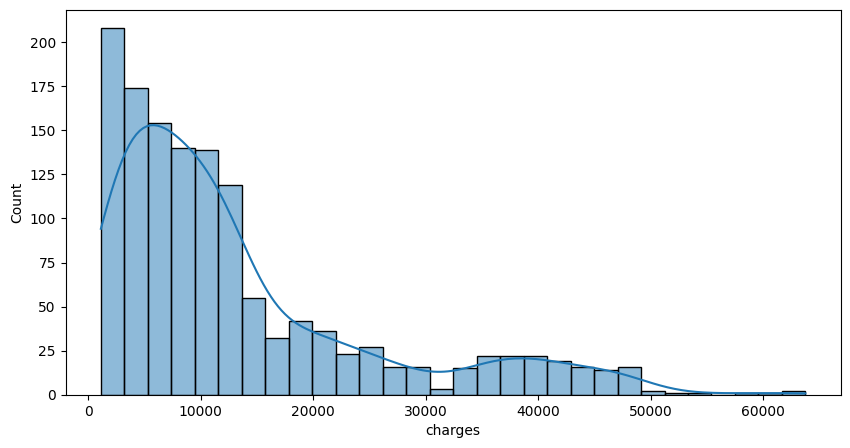

In [11]:
# EDA(Distribution of Values)

plt.figure(figsize=(10,5))
sns.histplot(df["charges"],kde=True)
plt.show()

ans.1=charges is not normally distributated it is left skewed

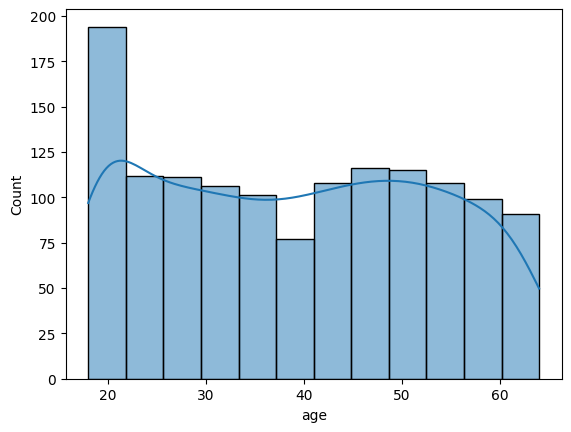

In [12]:
sns.histplot(df["age"],kde=True)
plt.show()

ans.2-Most of the peoplt are from 20 ages which is quite young people.

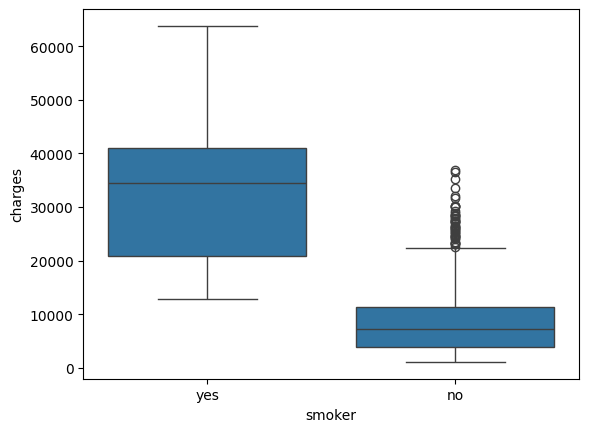

In [13]:
sns.boxplot(x="smoker",y="charges",data=df)
plt.show()


ans.3- smoker has higher charges values compare to non-smoker.smokers are paying approximately 3 times more than the non-smokers.

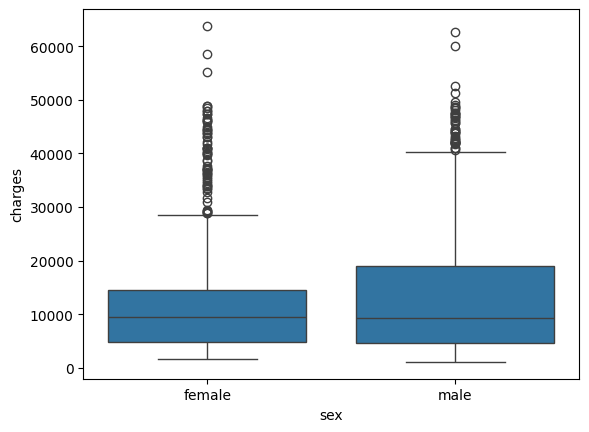

In [14]:
sns.boxplot(x="sex",y="charges",data=df)
plt.show()

In [14]:
ans.4- No,there is not,so significant difference in charges between male and female.but outliers are present in both the cases.

SyntaxError: invalid syntax (2692774839.py, line 1)

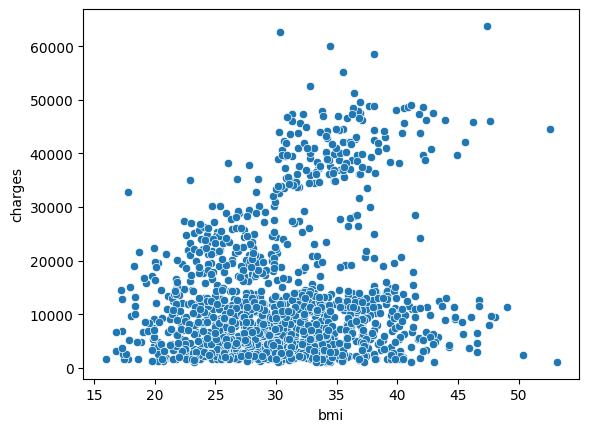

In [15]:
sns.scatterplot(x="bmi",y="charges",data=df)
plt.show()

ans-5.it is clearly seent that the bmi and charges have possitive relationship as the bmi increases charges also tend to increase.

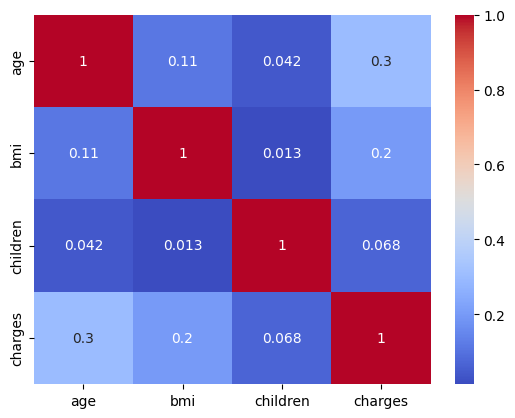

In [16]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.show()

In [ ]:
ans.5-age has the highest correlation with the chages and children has the lowest correlation with the charges,i don't think that any of the features has same kind of correlation.

In [ ]:
i.Liner Regression reauire feature scalling as there may be some features which have some difference like house predictions where age has a limitation and where person salary has much higher values than the age.
ii.Logistic Regression is also where we need feature scalling like a loan applicant has limited year of experience and the salary has huge values.
iii.KNN its based on nearest point that why there is no need of feature scalling.
iv.decision tree and random forest has the same kind of criteria thease are based on some condition that's why there is no requirement of feature scalling


In [17]:
print(df["sex"].value_counts())
print(df["region"].value_counts())
print(df["smoker"].value_counts())

sex
male      676
female    662
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
smoker
no     1064
yes     274
Name: count, dtype: int64


In [ ]:
# /// As We can see that sex and smoker has the only two unique categorical values so
# we can encoded them into numberial value by encoder so we can use these features in
# our machine learning model.///

from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

for col in ["sex","smoker"]:
    df[col]=le.fit_transform(df[col])

In [ ]:
# Inverseing the columns to its original values
for col in ["sex","smoker"]:
  df[col]=le.inverse_transform(df[col])

In [18]:
df["smoker"].value_counts()

,count
smoker,
no,1064
yes,274


In [19]:
df["sex"].value_counts()

,count
sex,
male,676
female,662


In [20]:
# our cetegorical column converted into 0 and 1.
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# # As we can see that region column still showing categorical column but it has more than 2 values presest show we can not use label encoder
# because it will provide series on 0 to 3 values which will lead to misslead our model by thinking it as order ordinal value and give higher
# weightage to the higer value so we need one hot endoding for this kind of features



In [21]:
# Now doing the encoding again with map function

df["sex"]=df["sex"].map({"female":0,
                         "male":1})


df["smoker"]=df["smoker"].map({"yes":1,
                         "no":0})

In [22]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [23]:
# Now we also convert the region column with the one hot encoding

df=pd.get_dummies(data=df,columns=["region"],drop_first=True)

In [24]:
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1338 non-null   int64  
 1   sex               1338 non-null   int64  
 2   bmi               1338 non-null   float64
 3   children          1338 non-null   int64  
 4   smoker            1338 non-null   int64  
 5   charges           1338 non-null   float64
 6   region_northwest  1338 non-null   bool   
 7   region_southeast  1338 non-null   bool   
 8   region_southwest  1338 non-null   bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 66.8 KB


In [26]:
# Now Creating x and y for the model processings

x=df.drop("charges",axis=1)
y=df["charges"]

In [27]:
# Now we are trying the split the data for the model and fit Regression Model for training
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [28]:
# Spliting the data into training and testing for modelling.
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)


In [29]:
#Checking the shape of the data

print(x_train.shape,x_test.shape)
print(y_train.shape,y_test.shape)

(1070, 8) (268, 8)
(1070,) (268,)


In [30]:
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [31]:
# Checking the Accuracy Score
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
print("Training Score :",model.score(x_train,y_train))
print("Testting Score :",model.score(x_test,y_test))
print("R2 Score :",r2_score(y_test,y_pred))
print("Mean Absolute Error :",mean_absolute_error(y_test,y_pred))
print("Mean Squared Error :",mean_squared_error(y_test,y_pred))
print("Root Mean Squared Error :",np.sqrt(mean_squared_error(y_test,y_pred)))


Training Score : 0.7417255854683333
Testting Score : 0.7835929767120723
R2 Score : 0.7835929767120723
Mean Absolute Error : 4181.1944737536505
Mean Squared Error : 33596915.85136146
Root Mean Squared Error : 5796.2846592762735


In [33]:
# Now we are checking the cofficient and intercept

print("Coeficient of model:",model.coef_)
print("Intercept of Model:",model.intercept_)

Coeficient of model: [ 2.56975706e+02 -1.85916916e+01  3.37092552e+02  4.25278784e+02
  2.36511289e+04 -3.70677326e+02 -6.57864297e+02 -8.09799354e+02]
Intercept of Model: -11931.219050326692


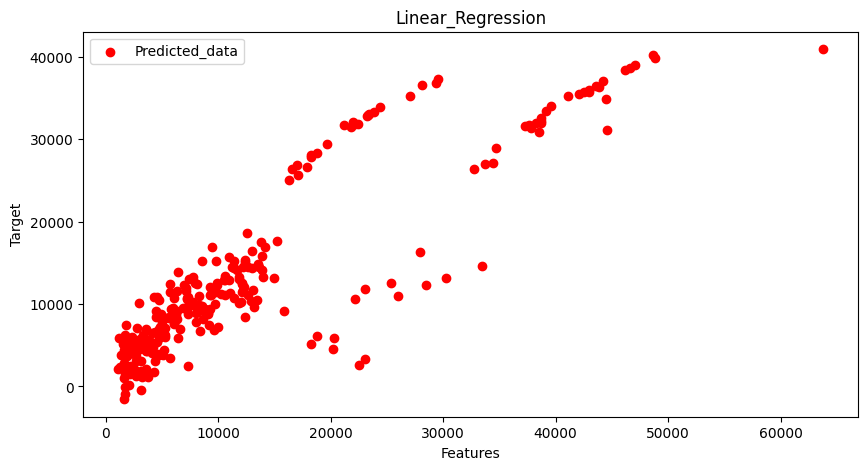

In [40]:
# Now we are trying to see the Visulization of the model

plt.figure(figsize=(10,5))
# plt.scatter(x,y,label="Actual_data",color="blue")
plt.scatter(y_test,y_pred,label="Predicted_data",color="red")
plt.xlabel("Features")
plt.ylabel("Target")
plt.title("Linear_Regression")
plt.legend()
plt.show()